<a href="https://colab.research.google.com/github/mmwaala/Martin_Mwaala/blob/main/ChatGPT_for_Finance_World_Championship_%E2%80%93_Martin_Mwaala_Advanced.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


MessageError: Error: credential propagation was unsuccessful

In [ ]:
file_path = "/content/drive/My Drive/Chat GPT/ChatGPT for Finance World Championship – Advanced Dataset.xlsx"



In [ ]:
import pandas as pd

df = pd.read_excel(file_path, sheet_name='Sheet1')  # Update sheet name if needed

# Display the first few rows
df.head()


,Date,Region,Product,Revenue,Cost,Units Sold,Customer Satisfaction,Profit
0,2020-01-01,South America,Product B,7284.69,2198.70,89,3.42,5085.99
1,2020-01-02,Australia,Product D,5808.37,2775.12,67,4.63,3033.25
2,2020-01-03,Asia,Product D,3444.13,4438.15,64,1.96,-994.02
3,2020-01-04,Australia,Product A,4714.49,3512.67,13,2.88,1201.82
4,2020-01-05,Australia,Product B,3686.57,2543.06,33,2.80,1143.51


In [ ]:
# Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Group data by Date and sum Revenue & COGS
trend_df = df.groupby('Date')[['Revenue', 'Cost']].sum().reset_index()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure 'Date' column is in datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Extract Year and Month
df['YearMonth'] = df['Date'].dt.to_period('M')

# Get the last date for each Year-Month
last_dates = df.groupby('YearMonth')['Date'].max().reset_index()

# Merge to keep only last-day records for each month
monthly_trend_df = df.merge(last_dates, on='Date', how='right')

# Filter only for 2020 and 2021
monthly_trend_df = monthly_trend_df[(monthly_trend_df['Date'].dt.year >= 2020) &
                                    (monthly_trend_df['Date'].dt.year <= 2021)]

# Group by last day of each month and sum Revenue & COGS
monthly_trend = monthly_trend_df.groupby('Date')[['Revenue', 'Cost']].sum().reset_index()


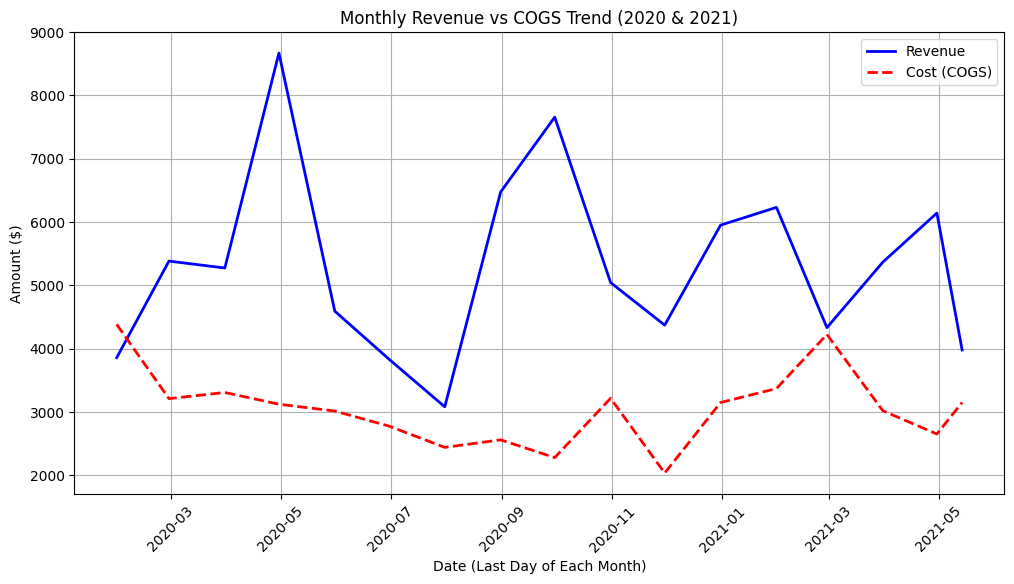

In [ ]:
# Plot Revenue vs COGS on the last day of each month
plt.figure(figsize=(12, 6))
plt.plot(monthly_trend['Date'], monthly_trend['Revenue'], label='Revenue', linewidth=2, color='blue')
plt.plot(monthly_trend['Date'], monthly_trend['Cost'], label='Cost (COGS)', linewidth=2, linestyle='dashed', color='red')

# Formatting the plot
plt.xlabel('Date (Last Day of Each Month)')
plt.ylabel('Amount ($)')
plt.title('Monthly Revenue vs COGS Trend (2020 & 2021)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

# Show the plot
plt.show()


In [ ]:
import pandas as pd

# Ensure 'Date' column is in datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Filter for 2020 and 2021 data
df_filtered = df[(df['Date'].dt.year >= 2020) & (df['Date'].dt.year <= 2021)]

# Aggregate Revenue, Cost, and Profit by Region
region_summary = df_filtered.groupby('Region')[['Revenue', 'Cost', 'Profit']].sum().reset_index()

# Convert Revenue, Cost, and Profit to whole numbers (no decimals)
region_summary['Revenue'] = region_summary['Revenue'].astype(int)
region_summary['Cost'] = region_summary['Cost'].astype(int)
region_summary['Profit'] = region_summary['Profit'].astype(int)

# Calculate % Profit as a percentage of the grand total profit and round to two decimal places
total_profit = region_summary['Profit'].sum()
region_summary['% Profit'] = (region_summary['Profit'] / total_profit * 100).round(2)

# Display the final table
print(region_summary)



          Region  Revenue    Cost  Profit  % Profit
0           Asia   492834  289786  203047     20.67
1      Australia   462868  278551  184316     18.76
2         Europe   492110  291691  200418     20.40
3  North America   520820  339181  181638     18.49
4  South America   551365  338360  213004     21.68


In [ ]:
import pandas as pd

# Ensure 'Date' column is in datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Filter for 2020 and 2021 data
df_filtered = df[(df['Date'].dt.year >= 2020) & (df['Date'].dt.year <= 2021)]

# Aggregate Revenue and Profit by Product
product_summary = df_filtered.groupby('Product')[['Revenue', 'Profit']].sum().reset_index()

# Convert Revenue and Profit to whole numbers (no decimals)
product_summary['Revenue'] = product_summary['Revenue'].astype(int)
product_summary['Profit'] = product_summary['Profit'].astype(int)

# Calculate Profit as a percentage of the grand total profit
total_profit = product_summary['Profit'].sum()
product_summary['Profit Percentage'] = (product_summary['Profit'] / total_profit * 100).round(2)

# Display the table
print(product_summary)



     Product  Revenue  Profit  Profit Percentage
0  Product A   728198  287535              29.27
1  Product B   636112  246036              25.04
2  Product C   643812  269817              27.46
3  Product D   511875  179037              18.22


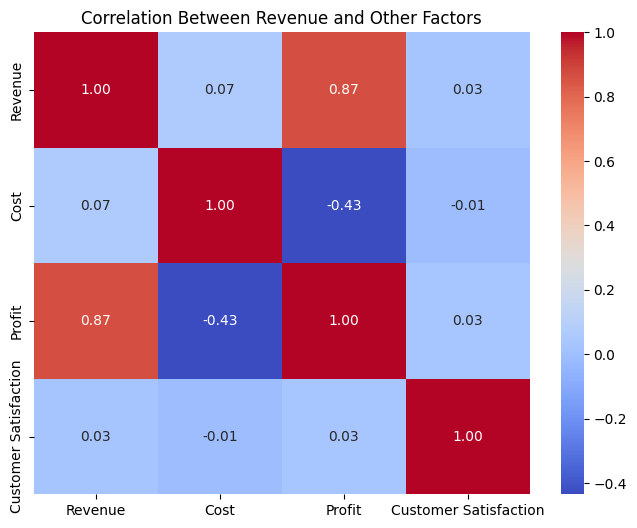

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure 'Date' column is in datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Filter for 2020 and 2021 data
df_filtered = df[(df['Date'].dt.year >= 2020) & (df['Date'].dt.year <= 2021)]

# Selecting key numerical factors for correlation analysis
correlation_matrix = df_filtered[['Revenue', 'Cost', 'Profit', 'Customer Satisfaction']].corr()

# Plot heatmap of correlations
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Revenue and Other Factors")
plt.show()




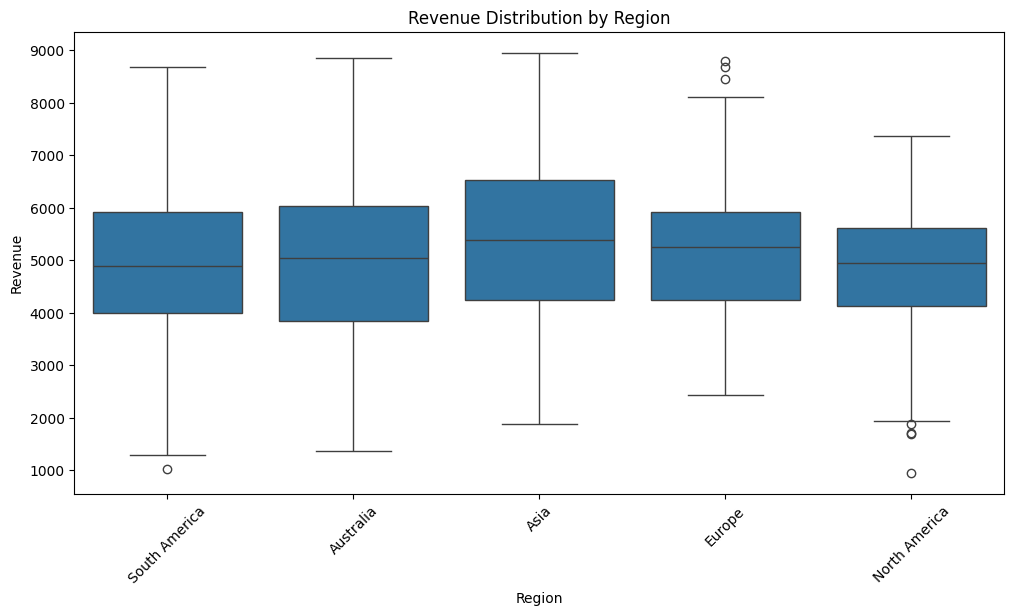

In [ ]:
# Revenue distribution by Region
plt.figure(figsize=(12, 6))
sns.boxplot(x='Region', y='Revenue', data=df_filtered)
plt.title("Revenue Distribution by Region")
plt.xticks(rotation=45)
plt.show()



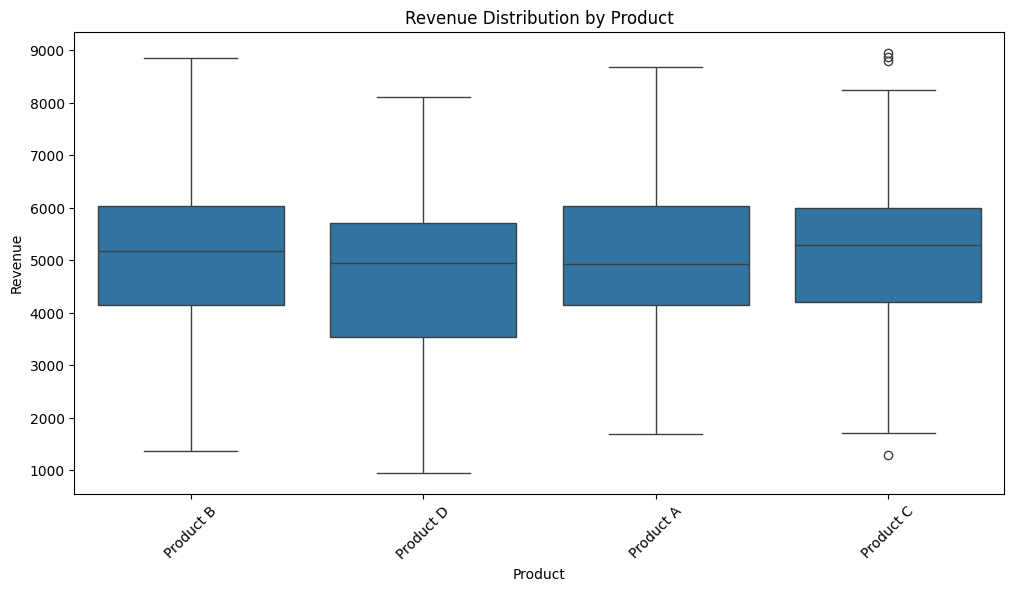

In [ ]:
# Revenue distribution by Product
plt.figure(figsize=(12, 6))
sns.boxplot(x='Product', y='Revenue', data=df_filtered)
plt.title("Revenue Distribution by Product")
plt.xticks(rotation=45)
plt.show()



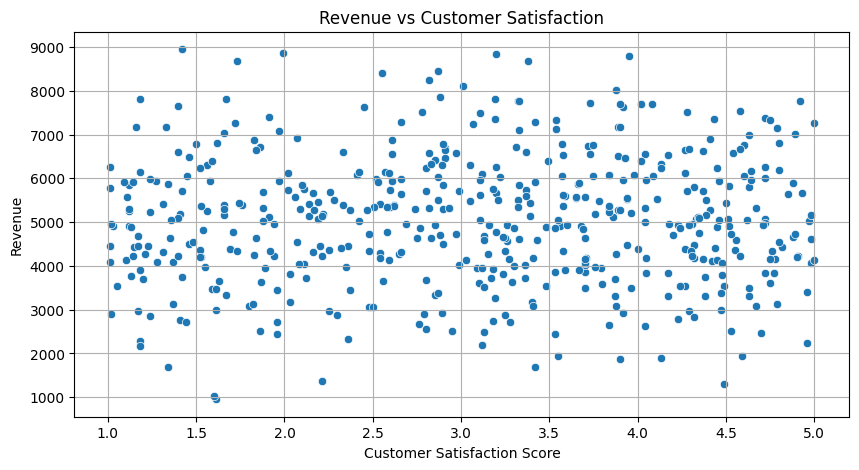

In [ ]:
# Revenue vs Customer Satisfaction
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df_filtered['Customer Satisfaction'], y=df_filtered['Revenue'])
plt.title("Revenue vs Customer Satisfaction")
plt.xlabel("Customer Satisfaction Score")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import statsmodels.api as sm

# Ensure 'Date' column is in datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Filter for 2020 and 2021 data
df_filtered = df[(df['Date'].dt.year >= 2020) & (df['Date'].dt.year <= 2021)].copy()

# Drop missing values
df_filtered = df_filtered.dropna()

# Drop non-numeric columns before encoding
df_filtered = df_filtered.drop(columns=['Date'])

# Encode categorical variables (Region and Product) for regression
df_filtered = pd.get_dummies(df_filtered, columns=['Region', 'Product'], drop_first=True)

# Ensure all data types are numeric
df_filtered = df_filtered.apply(pd.to_numeric, errors='coerce')

# Select independent variables (excluding non-numeric columns)
independent_vars = ['Cost', 'Units Sold', 'Customer Satisfaction'] + [col for col in df_filtered.columns if col.startswith('Region_') or col.startswith('Product_')]

# Define dependent (Revenue) and independent variables
X = df_filtered[independent_vars]  # Predictors
y = df_filtered['Revenue']         # Target variable

# Convert to numpy arrays to avoid dtype errors
X = X.astype(float)
y = y.astype(float)

# Add constant to the model
X = sm.add_constant(X)

# Fit the multiple linear regression model
model = sm.OLS(y, X).fit()

# Display the summary of the regression results
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                Revenue   R-squared:                       0.041
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     2.114
Date:                Wed, 05 Feb 2025   Prob (F-statistic):             0.0221
Time:                        17:57:10   Log-Likelihood:                -4344.5
No. Observations:                 500   AIC:                             8711.
Df Residuals:                     489   BIC:                             8757.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                  4882.35